# 02 探索性資料分析 (EDA)
本筆記本負責載入預處理後的資料，進行深入的資料探索與可視化分析。包含統計學型態分類分析、單變量分佈、時間序列分佈以及特徵相關性分析。

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.family'] = ['Microsoft JhengHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 添加專案根目錄到 Python 路徑
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 匯入資料載入系統
from src.data_loader import DataLoader, ConfigLoader

# 載入配置
config = ConfigLoader.load_config(project_root / "config.yaml")
loader = DataLoader(config)

print("✅ 環境初始化完成")

2026-05-11 15:31:10,494 - src.data_loader - INFO - ✅ 設定檔已載入: c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\config.yaml


✅ 環境初始化完成


In [2]:
# 載入預處理後的資料
df = loader.load_interim_data("01_preprocessed.csv")
print(f"資料形狀: {df.shape}")
display(df.head())

2026-05-11 15:32:18,364 - src.data_loader - INFO - 📖 讀取中間資料: c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\data\interim\01_preprocessed.csv
2026-05-11 15:32:18,468 - src.data_loader - INFO - ✅ 中間資料已載入 | 形狀: (10345, 27)


資料形狀: (10345, 27)


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,...,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_is_weekend,debt_to_income_ratio_log,purchase_amount_log,monthly_income_log,missed_payments_log1p,repayment_delay_days_log1p
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,...,2023,6,10,5,1,-2.617826,8.517193,11.135020,0.693147,2.639057
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,...,2024,10,7,0,0,-1.910032,6.978428,8.888460,0.693147,2.639057
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,...,2023,4,5,2,0,-2.118236,8.517193,10.635429,1.098612,2.995732
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,...,2023,6,24,5,1,-1.263536,8.313075,9.576611,1.791759,2.944439
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,...,2024,10,19,5,1,-2.148163,8.517193,10.665356,0.000000,0.000000


## 1. 變數統計分類與摘要
根據統計學型態進行分類分析。

In [3]:
data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'default_flag'],
    'Ordinal': ['customer_segment'],
    'Interval': ['credit_score', 'transaction_date'],
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
              'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 
              'debt_to_income_ratio', 'risk_score']  
}

### 1.1 類別型變數 (Categorical)
分析眾數、比例與分佈。

=== Categorical 欄位統計 ===

employment_type:
  類別數量: 4
  眾數: Salaried (出現 2632 次)
  所有值: {'Salaried': 2632, 'Unemployed': 2632, 'Self-Employed': 2550, 'Student': 2531}

  各類別比例:
    Salaried: 2632 (25.4%)
    Unemployed: 2632 (25.4%)
    Self-Employed: 2550 (24.6%)
    Student: 2531 (24.5%)


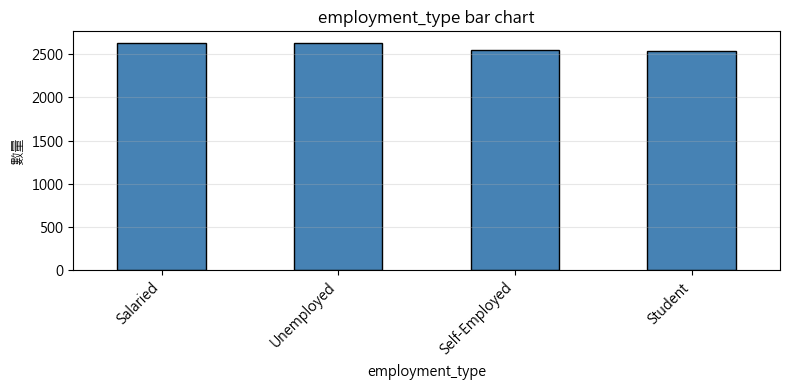


product_category:
  類別數量: 5
  眾數: Fashion (出現 2166 次)
  所有值: {'Fashion': 2166, 'Electronics': 2085, 'Beauty': 2072, 'Home': 2052, 'Sports': 1970}

  各類別比例:
    Fashion: 2166 (20.9%)
    Electronics: 2085 (20.2%)
    Beauty: 2072 (20.0%)
    Home: 2052 (19.8%)
    Sports: 1970 (19.0%)


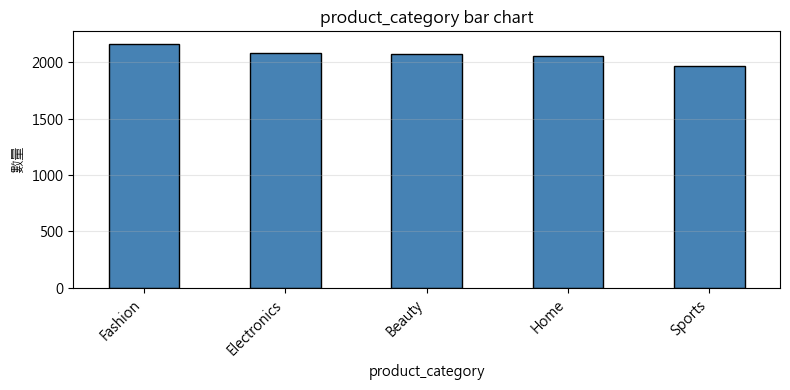


location:
  類別數量: 6
  眾數: Germany (出現 1760 次)
  所有值: {'Germany': 1760, 'Canada': 1740, 'USA': 1736, 'India': 1723, 'Australia': 1722, 'UK': 1664}

  各類別比例:
    Germany: 1760 (17.0%)
    Canada: 1740 (16.8%)
    USA: 1736 (16.8%)
    India: 1723 (16.7%)
    Australia: 1722 (16.6%)
    UK: 1664 (16.1%)


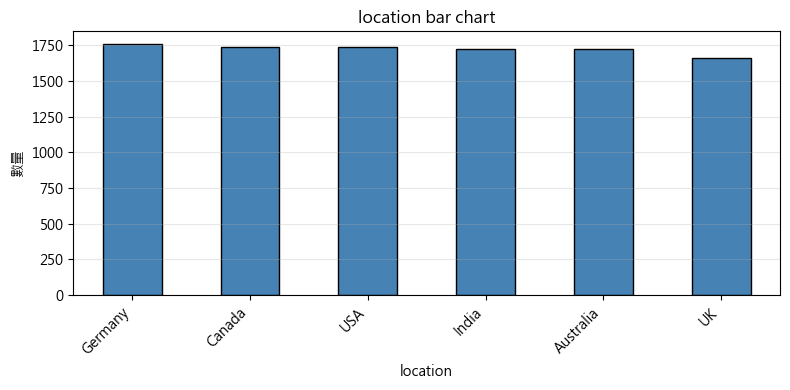


default_flag:
  類別數量: 2
  眾數: 0 (出現 6305 次)
  所有值: {0: 6305, 1: 4040}

  各類別比例:
    0: 6305 (60.9%)
    1: 4040 (39.1%)


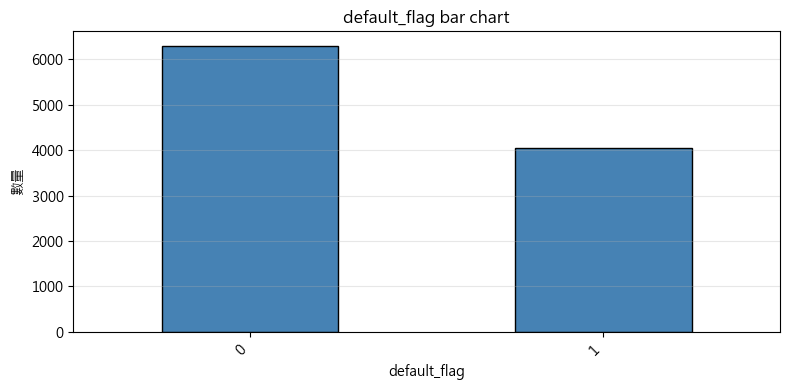

In [4]:
# Categorical統計
print("=== Categorical 欄位統計 ===")
for col in data_types['Categorical']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  類別數量: {df[col].nunique()}")
        print(f"  眾數: {df[col].mode().iloc[0]} (出現 {df[col].value_counts().iloc[0]} 次)")
        print(f"  所有值: {df[col].value_counts().to_dict()}")
        
        # 計算各類別的比例
        print(f"\n  各類別比例:")
        value_counts = df[col].value_counts()
        total_count = len(df[col])
        for category, count in value_counts.items():
            percentage = (count / total_count) * 100
            print(f"    {category}: {count} ({percentage:.1f}%)")
        
        # 畫長條圖
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
        plt.title(f"{col} bar chart")
        plt.xlabel(col)
        plt.ylabel('數量')
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### 1.2 順序型變數 (Ordinal)
將 `customer_segment` 映射為數值進行分析。

=== Ordinal 欄位統計 ===
Ordinal 欄位清單: ['customer_segment']
資料集欄位包含 Ordinal 欄位: ['customer_segment']

customer_segment:
  數值映射: {'Low Risk': 1, 'Medium Risk': 2, 'High Risk': 3}
  總數: 10345
  中位數: 3.00
  眾數: 3
  最小值: 1
  最大值: 3

  各類別比例:
    High Risk: 7569 (73.2%)
    Medium Risk: 2200 (21.3%)
    Low Risk: 576 (5.6%)


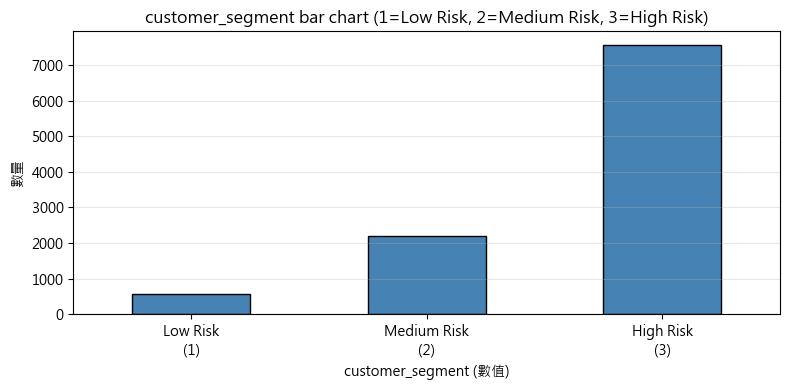

In [5]:
# Ordinal 統計
print("=== Ordinal 欄位統計 ===")
print(f"Ordinal 欄位清單: {data_types['Ordinal']}")
print(f"資料集欄位包含 Ordinal 欄位: {[col for col in data_types['Ordinal'] if col in df.columns]}")

# 定義 customer_segment 的順序映射
segment_mapping = {'Low Risk': 1, 'Medium Risk': 2, 'High Risk': 3}

for col in data_types['Ordinal']:
    if col in df.columns:
        print(f"\n{col}:")
        
        # 特殊處理 customer_segment：轉換為數值
        if col == 'customer_segment':
            df_numeric = df[col].map(segment_mapping)
            print(f"  數值映射: {segment_mapping}")
            print(f"  總數: {df_numeric.count()}")
            print(f"  中位數: {df_numeric.median():.2f}")
            print(f"  眾數: {df_numeric.mode().iloc[0]}")
            print(f"  最小值: {df_numeric.min()}")
            print(f"  最大值: {df_numeric.max()}")
            
            # 計算各類別的比例
            print(f"\n  各類別比例:")
            value_counts = df[col].value_counts()
            total_count = len(df[col])
            for category, count in value_counts.items():
                percentage = (count / total_count) * 100
                print(f"    {category}: {count} ({percentage:.1f}%)")
            
            # 畫長條圖（使用數值版本）
            plt.figure(figsize=(8, 4))
            df_numeric.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart (1=Low Risk, 2=Medium Risk, 3=High Risk)")
            plt.xlabel(f"{col} (數值)")
            plt.ylabel('數量')
            plt.xticks([0, 1, 2], ['Low Risk\n(1)', 'Medium Risk\n(2)', 'High Risk\n(3)'], rotation=0)
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()    

### 1.3 區間型變數 (Interval)
分析數值分佈與集中趨勢。

=== Interval 欄位統計 (非時間型) ===
Interval 欄位清單: ['credit_score', 'transaction_date']
資料集欄位包含 Interval 欄位: ['credit_score', 'transaction_date']

credit_score:
  總數: 10345
  平均: 448.18
  中位數: 403.00
  眾數: 300
  最小值: 300
  最大值: 850
  標準差: 136.52


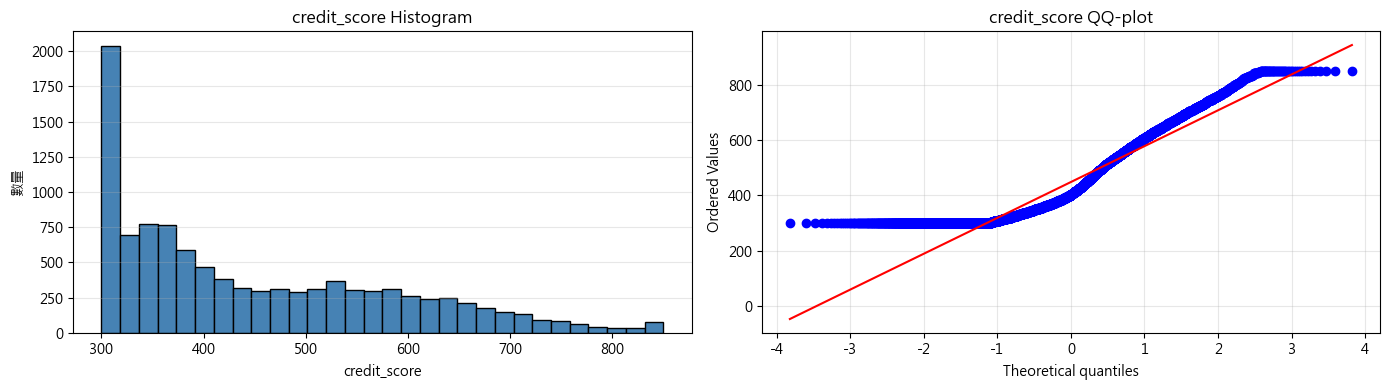

In [6]:
# Interval 統計 (非時間型)
print("=== Interval 欄位統計 (非時間型) ===")
print(f"Interval 欄位清單: {data_types['Interval']}")
print(f"資料集欄位包含 Interval 欄位: {[col for col in data_types['Interval'] if col in df.columns]}")

for col in data_types['Interval']:
    if col in df.columns and col != 'transaction_date':  # transaction_date 在下面單獨處理
        print(f"\n{col}:")
        print(f"  總數: {df[col].count()}")
        print(f"  平均: {df[col].mean():.2f}")
        print(f"  中位數: {df[col].median():.2f}")
        print(f"  眾數: {df[col].mode().iloc[0]}")
        print(f"  最小值: {df[col].min()}")
        print(f"  最大值: {df[col].max()}")
        print(f"  標準差: {df[col].std():.2f}")
        
        # 畫直方圖與 QQ-plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # 直方圖
        axes[0].hist(df[col], bins=30, color='steelblue', edgecolor='black')
        axes[0].set_title(f"{col} Histogram")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('數量')
        axes[0].grid(axis='y', alpha=0.3)
        
        # QQ-plot
        stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title(f"{col} QQ-plot")
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()

### 1.4 比率型變數 (Ratio)
分析數值分佈與集中趨勢。

=== Ratio 欄位統計 ===

age:


count    10345.000000
mean        38.559884
std         12.131789
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

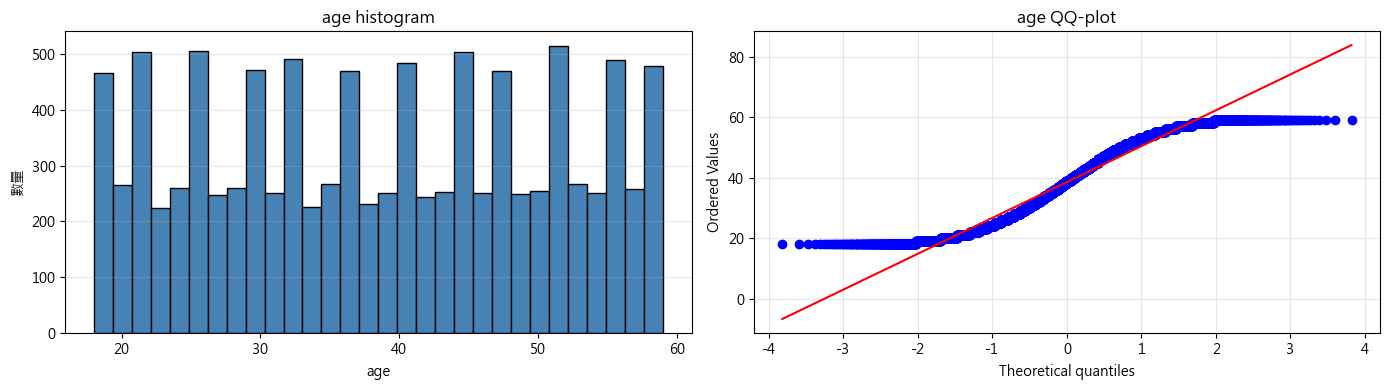


monthly_income:


count     10345.000000
mean      35053.381898
std       27084.517277
min        5000.000000
25%       12207.020000
50%       23800.520000
75%       55276.930000
max      145767.120000
Name: monthly_income, dtype: float64

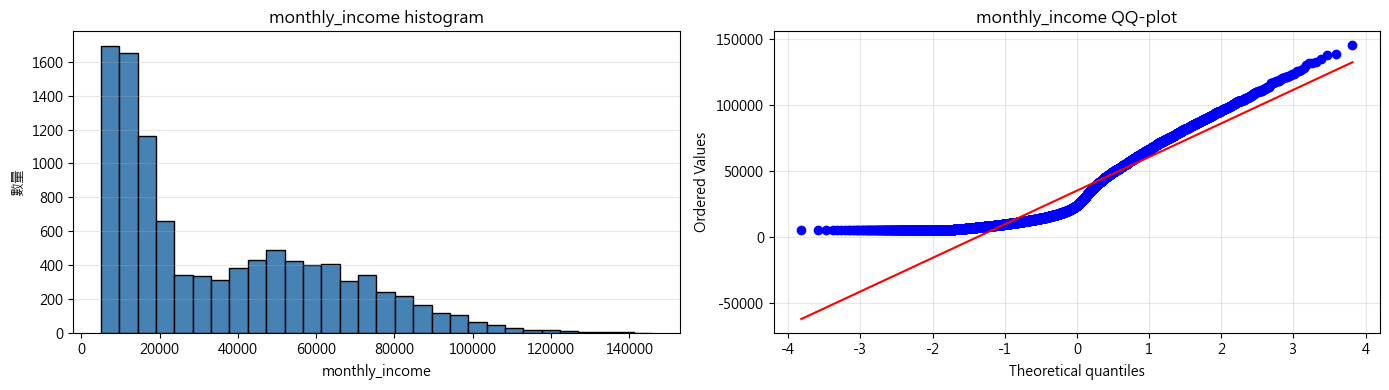


purchase_amount:


count    10345.000000
mean      3979.402721
std       1500.828483
min        100.000000
25%       2990.720000
50%       5000.000000
75%       5000.000000
max       5000.000000
Name: purchase_amount, dtype: float64

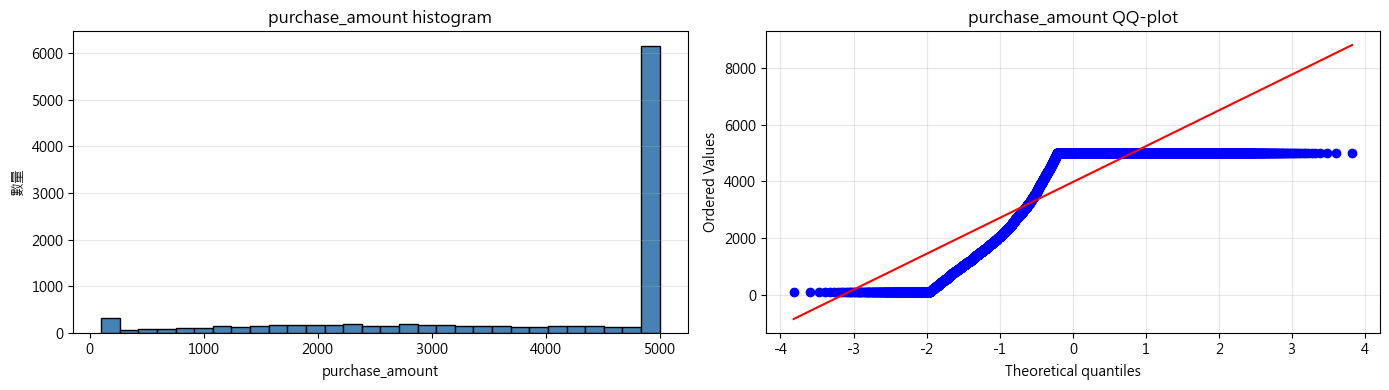


bnpl_installments:


count    10345.000000
mean         7.477525
std          3.362867
min          3.000000
25%          3.000000
50%          9.000000
75%          9.000000
max         12.000000
Name: bnpl_installments, dtype: float64

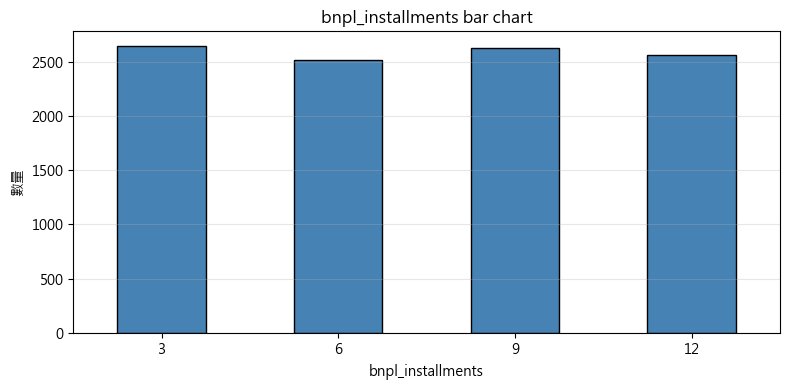


repayment_delay_days:


count    10345.000000
mean         8.742774
std          6.781849
min          0.000000
25%          2.000000
50%          9.000000
75%         14.000000
max         33.000000
Name: repayment_delay_days, dtype: float64

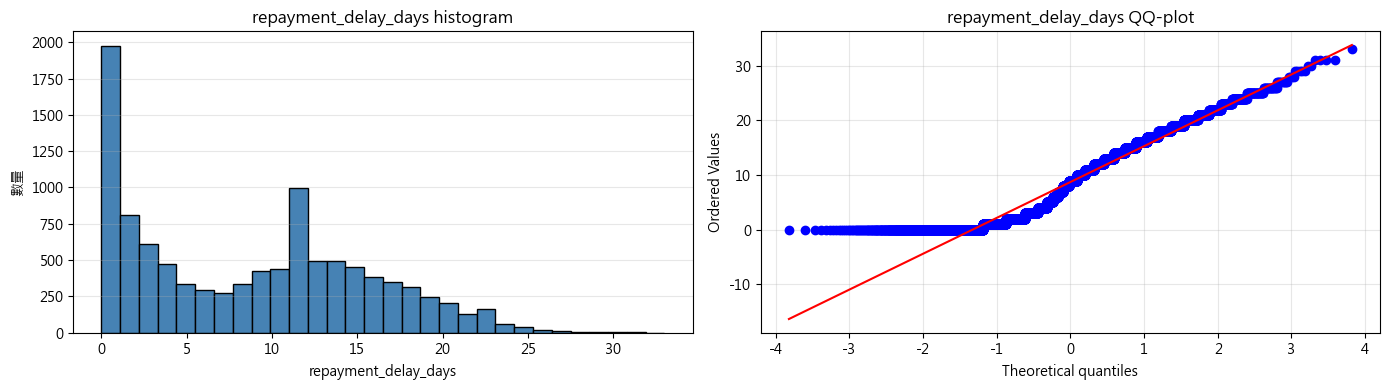


missed_payments:


count    10345.000000
mean         1.015950
std          0.996726
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: missed_payments, dtype: float64

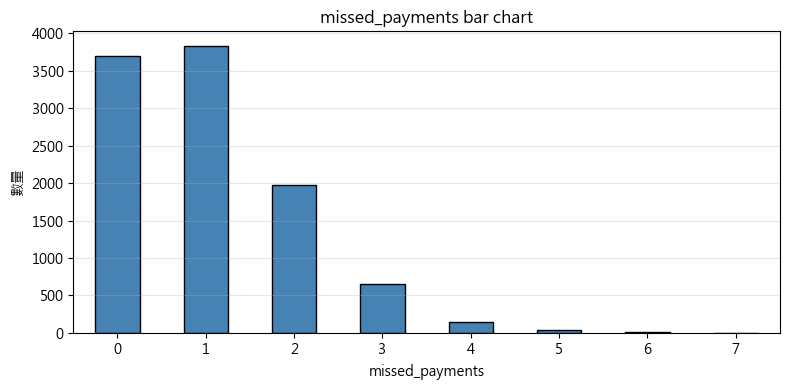


app_usage_frequency:


count    10345.000000
mean         5.524101
std          2.590364
min          1.000000
25%          3.300000
50%          5.550000
75%          7.750000
max         10.000000
Name: app_usage_frequency, dtype: float64

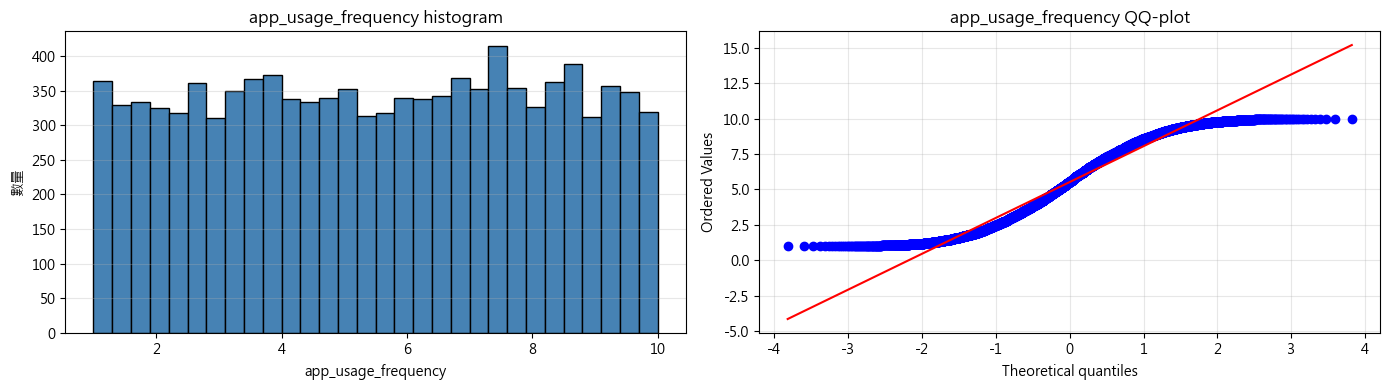


debt_to_income_ratio:


count    10345.000000
mean         0.181071
std          0.124887
min          0.000811
25%          0.080187
50%          0.138263
75%          0.268300
max          0.723460
Name: debt_to_income_ratio, dtype: float64

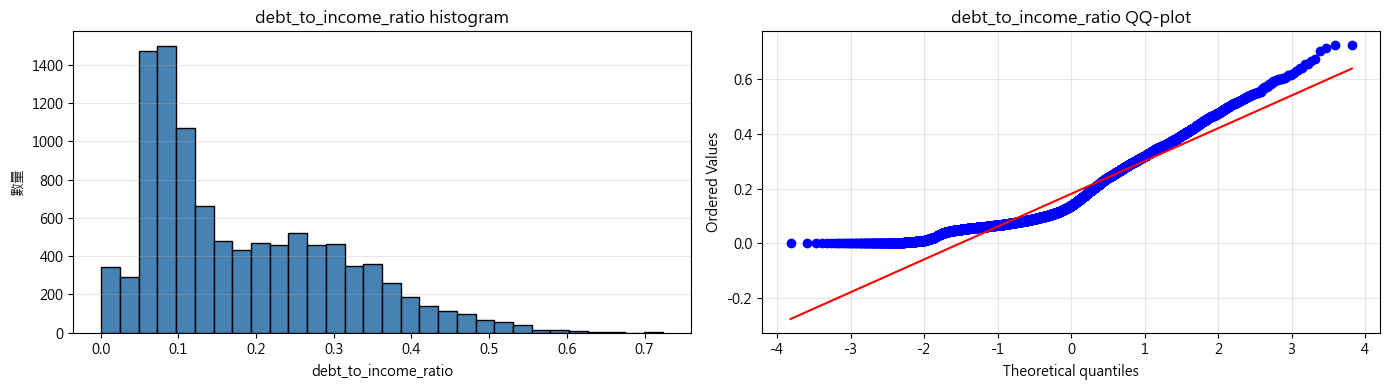


risk_score:


count    10345.000000
mean       198.534094
std         67.541384
min          0.000000
25%        153.600000
50%        202.800000
75%        250.800000
max        398.000000
Name: risk_score, dtype: float64

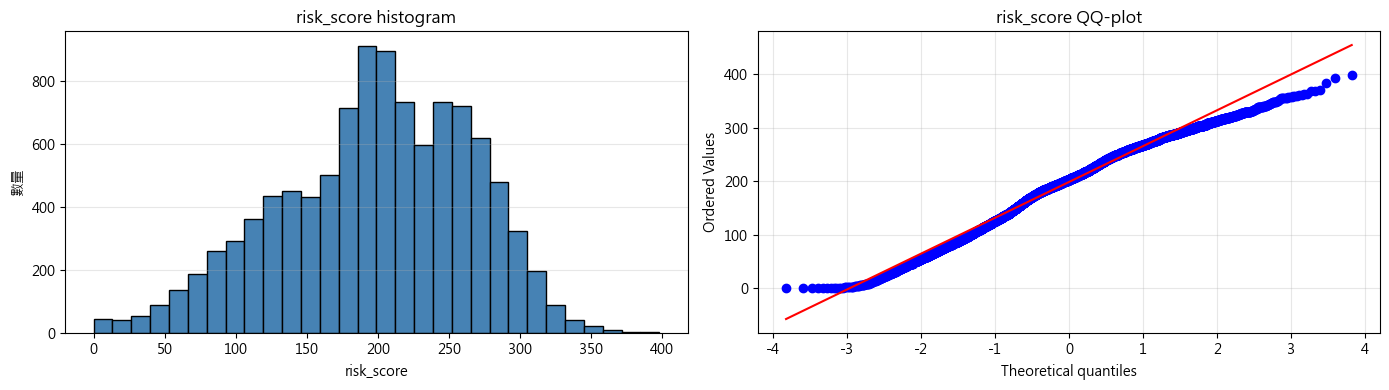

In [7]:
#Ratio統計
print("=== Ratio 欄位統計 ===")
for col in data_types['Ratio']:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].describe().T)
        
        # 特殊處理：特定欄位使用長條圖
        if col in ['default_flag', 'missed_payments', 'bnpl_installments']:
            plt.figure(figsize=(8, 4))
            df[col].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart")
            plt.xlabel(col)
            plt.ylabel('數量')
            plt.grid(axis='y', alpha=0.3)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            # 其他欄位使用直方圖與 QQ-plot
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # 直方圖
            axes[0].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
            axes[0].set_title(f"{col} histogram")
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('數量')
            axes[0].grid(axis='y', alpha=0.3)
            
            # QQ-plot
            stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
            axes[1].set_title(f"{col} QQ-plot")
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()

## 2. 時間序列特徵分析
觀察交易在不同時間維度的分佈。

=== 時間型 Interval 統計與特徵工程 ===
非時間型 Interval 欄位 'credit_score' 在其他地方處理

transaction_date:
  總數: 10345
  開始時間: 2023-01-01 00:00:00
  結束時間: 2024-12-31 00:00:00
  時間跨度: 730 天
  缺失值: 0

  提取的特徵:
    - transaction_date_year
    - transaction_date_month
    - transaction_date_day
    - transaction_date_dayofweek (0=Monday, 6=Sunday)
    - transaction_date_is_weekend (1=Weekend, 0=Weekday)

  各時間特徵比例:

    transaction_date_year:
      2023: 5145 (49.7%)
      2024: 5200 (50.3%)

    transaction_date_month:
      1月: 899 (8.7%)
      2月: 823 (8.0%)
      3月: 895 (8.7%)
      4月: 858 (8.3%)
      5月: 808 (7.8%)
      6月: 862 (8.3%)
      7月: 874 (8.4%)
      8月: 868 (8.4%)
      9月: 876 (8.5%)
      10月: 853 (8.2%)
      11月: 868 (8.4%)
      12月: 861 (8.3%)

    transaction_date_dayofweek:
      Monday: 1481 (14.3%)
      Tuesday: 1514 (14.6%)
      Wednesday: 1462 (14.1%)
      Thursday: 1476 (14.3%)
      Friday: 1480 (14.3%)
      Saturday: 1410 (13.6%)
      Sunday: 1522 (14.7%)

    transac

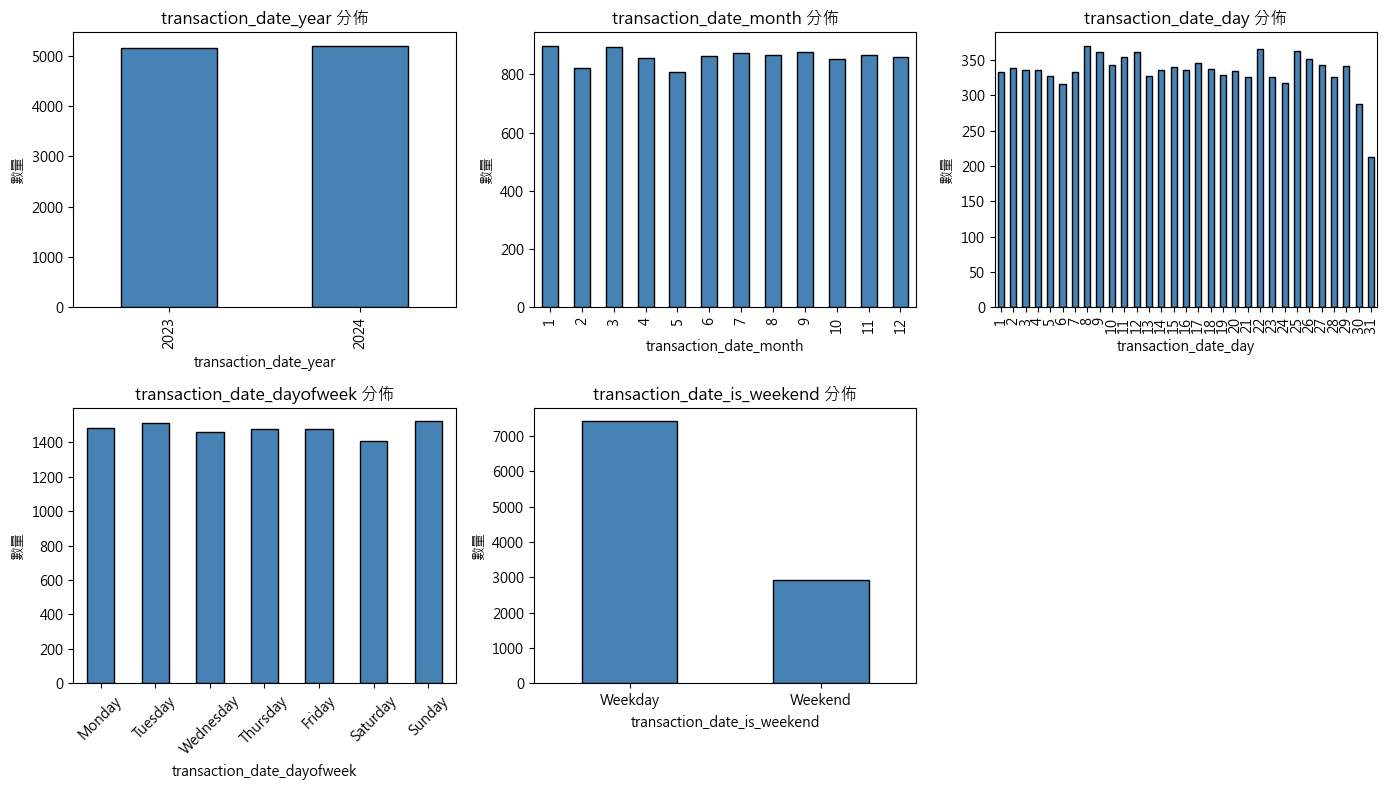

In [9]:
# 時間型 Interval 統計與特徵工程
print("=== 時間型 Interval 統計與特徵工程 ===")
for col in data_types['Interval']:
    if col in df.columns and col == 'transaction_date':  # 只處理 transaction_date
        print(f"\n{col}:")
        # 轉換為 datetime 如果還未轉換 (避免 dtype 為 'string' 而被跳過)
        if not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # 統計摘要
        print(f"  總數: {df[col].count()}")
        print(f"  開始時間: {df[col].min()}")
        print(f"  結束時間: {df[col].max()}")
        print(f"  時間跨度: {(df[col].max() - df[col].min()).days} 天")
        print(f"  缺失值: {df[col].isna().sum()}")
        
        # 時間特徵工程：提取年、月、日、星期幾、是否週末
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek  # 0=Monday, 6=Sunday
        df[f'{col}_is_weekend'] = df[col].dt.dayofweek.isin([5, 6]).astype(int)  # 1=Weekend, 0=Weekday
        
        print(f"\n  提取的特徵:")
        print(f"    - {col}_year")
        print(f"    - {col}_month")
        print(f"    - {col}_day")
        print(f"    - {col}_dayofweek (0=Monday, 6=Sunday)")
        print(f"    - {col}_is_weekend (1=Weekend, 0=Weekday)")
        
        # 各時間特徵的比例統計
        print(f"\n  各時間特徵比例:")
        
        # Year 比例
        print(f"\n    {col}_year:")
        year_counts = df[f'{col}_year'].value_counts().sort_index()
        total_count = len(df)
        for year, count in year_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {int(year)}: {count} ({percentage:.1f}%)")
        
        # Month 比例
        print(f"\n    {col}_month:")
        month_counts = df[f'{col}_month'].value_counts().sort_index()
        for month, count in month_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {int(month)}月: {count} ({percentage:.1f}%)")
        
        # Day of Week 比例
        print(f"\n    {col}_dayofweek:")
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dow_counts = df[f'{col}_dayofweek'].value_counts().sort_index()
        for dow, count in dow_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {day_names[int(dow)]}: {count} ({percentage:.1f}%)")
        
        # Is Weekend 比例
        print(f"\n    {col}_is_weekend:")
        weekend_counts = df[f'{col}_is_weekend'].value_counts().sort_index()
        weekend_labels = ['Weekday', 'Weekend']
        for weekend, count in weekend_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {weekend_labels[int(weekend)]}: {count} ({percentage:.1f}%)")
        
        # 繪製各特徵的分佈
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        
        # Year
        df[f'{col}_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
        axes[0, 0].set_title(f'{col}_year 分佈')
        axes[0, 0].set_ylabel('數量')
        
        # Month
        df[f'{col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
        axes[0, 1].set_title(f'{col}_month 分佈')
        axes[0, 1].set_ylabel('數量')
        
        # Day
        df[f'{col}_day'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='black')
        axes[0, 2].set_title(f'{col}_day 分佈')
        axes[0, 2].set_ylabel('數量')
        
        # Day of Week
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df[f'{col}_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
        axes[1, 0].set_title(f'{col}_dayofweek 分佈')
        axes[1, 0].set_ylabel('數量')
        axes[1, 0].set_xticklabels(day_names, rotation=45)
        
        # Is Weekend
        df[f'{col}_is_weekend'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
        axes[1, 1].set_title(f'{col}_is_weekend 分佈')
        axes[1, 1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
        axes[1, 1].set_ylabel('數量')
        
        # 隱藏最後一個子圖
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    elif col == 'transaction_date':
        pass  # 已處理
    else:
        print(f"非時間型 Interval 欄位 '{col}' 在其他地方處理")

In [10]:

# 日期時間型欄位處理（已在上面 Interval 統計中完成）
print("=== 日期時間型欄位轉換完成 ===")
print(f"transaction_date 型態: {df['transaction_date'].dtype}")
print(f"時間範圍: {df['transaction_date'].min()} 到 {df['transaction_date'].max()}")
print(f"缺失值: {df['transaction_date'].isna().sum()}")

=== 日期時間型欄位轉換完成 ===
transaction_date 型態: datetime64[us]
時間範圍: 2023-01-01 00:00:00 到 2024-12-31 00:00:00
缺失值: 0


## 3. 相關性分析 (Spearman)
對類別變數進行 One-Hot 編碼後計算斯皮爾曼相關係數。

=== 相關係數分析 (One-Hot Encoding + Spearman) ===
進行 One-Hot Encoding 的欄位:
  - employment_type -> ['employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed']
  - product_category -> ['product_category_Beauty', 'product_category_Electronics', 'product_category_Fashion', 'product_category_Home', 'product_category_Sports']
  - location -> ['location_Australia', 'location_Canada', 'location_Germany', 'location_India', 'location_UK', 'location_USA']
  - default_flag -> ['default_flag_0', 'default_flag_1']
transaction_date (原始 datetime 列) 已移除，使用提取的時間特徵代替

分析的欄位 (21 個): ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_dayofweek', 'transaction_is_weekend', 'debt_to_income_ratio_log', 'purchase_amount_log', 'monthly_income_log', 'misse

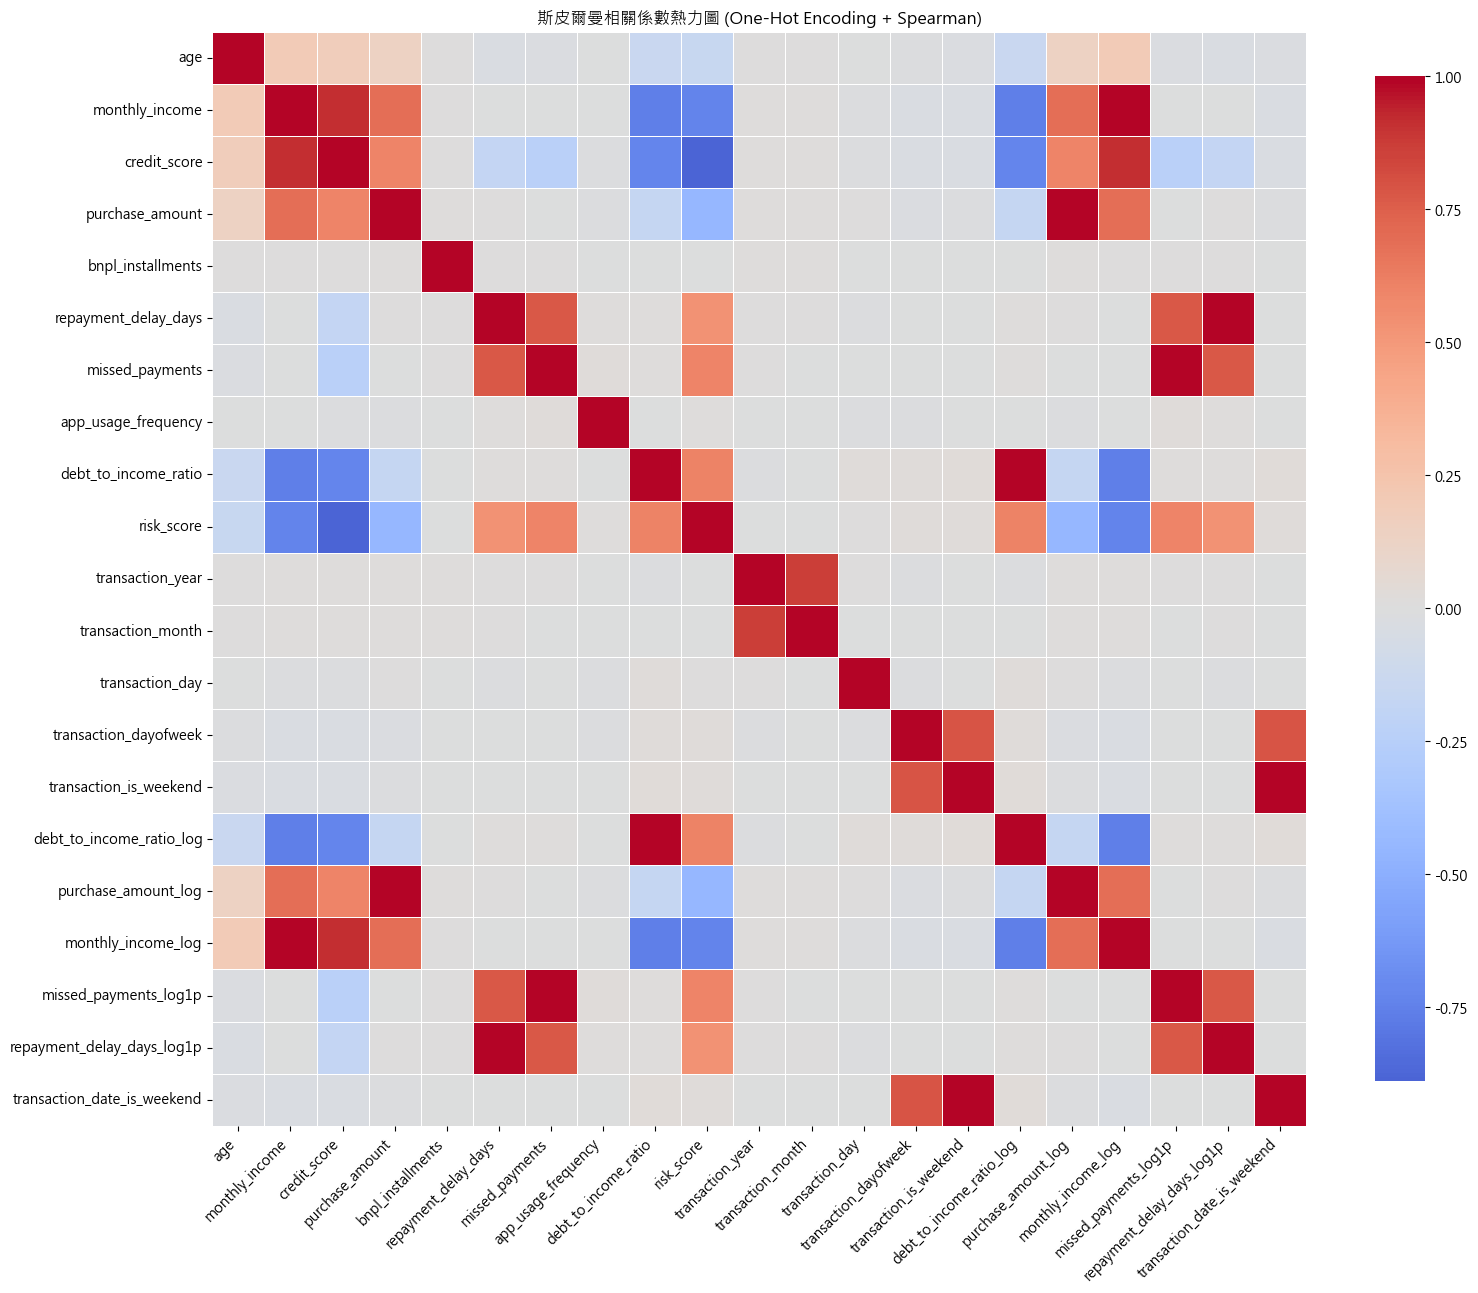


斯皮爾曼相關係數矩陣:


,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,app_usage_frequency,debt_to_income_ratio,risk_score,...,transaction_month,transaction_day,transaction_dayofweek,transaction_is_weekend,debt_to_income_ratio_log,purchase_amount_log,monthly_income_log,missed_payments_log1p,repayment_delay_days_log1p,transaction_date_is_weekend
age,1.000000,0.202487,0.175354,0.129444,0.006057,-0.027591,-0.025147,0.001979,-0.137650,-0.157483,...,0.008192,-0.009783,-0.014666,-0.021600,-0.137650,0.129444,0.202487,-0.025147,-0.027591,-0.021600
monthly_income,0.202487,1.000000,0.917798,0.683467,0.008456,-0.005765,-0.009993,-0.010355,-0.763407,-0.735334,...,0.012486,-0.012424,-0.030123,-0.031562,-0.763407,0.683467,1.000000,-0.009993,-0.005765,-0.031562
credit_score,0.175354,0.917798,1.000000,0.599005,0.010397,-0.175262,-0.234733,-0.013410,-0.731247,-0.888907,...,0.011648,-0.012902,-0.029929,-0.029390,-0.731247,0.599005,0.917798,-0.234733,-0.175262,-0.029390
purchase_amount,0.129444,0.683467,0.599005,1.000000,0.016228,0.008083,0.001119,-0.012417,-0.171407,-0.453112,...,0.015432,0.004726,-0.019748,-0.014936,-0.171407,1.000000,0.683467,0.001119,0.008083,-0.014936
bnpl_installments,0.006057,0.008456,0.010397,0.016228,1.000000,0.006689,0.006454,-0.002730,0.000850,-0.003048,...,0.012521,-0.010661,0.001577,-0.000367,0.000850,0.016228,0.008456,0.006454,0.006689,-0.000367
repayment_delay_days,-0.027591,-0.005765,-0.175262,0.008083,0.006689,1.000000,0.774901,0.018086,0.011994,0.528522,...,0.005112,-0.014652,0.000007,-0.001517,0.011994,0.008083,-0.005765,0.774901,1.000000,-0.001517
missed_payments,-0.025147,-0.009993,-0.234733,0.001119,0.006454,0.774901,1.000000,0.019884,0.012274,0.597218,...,0.003798,-0.010109,-0.003537,-0.005074,0.012274,0.001119,-0.009993,1.000000,0.774901,-0.005074
app_usage_frequency,0.001979,-0.010355,-0.013410,-0.012417,-0.002730,0.018086,0.019884,1.000000,0.000793,0.018502,...,-0.002874,-0.012609,-0.014416,-0.002567,0.000793,-0.012417,-0.010355,0.019884,0.018086,-0.002567
debt_to_income_ratio,-0.137650,-0.763407,-0.731247,-0.171407,0.000850,0.011994,0.012274,0.000793,1.000000,0.605571,...,-0.006449,0.020627,0.021821,0.028334,1.000000,-0.171407,-0.763407,0.012274,0.011994,0.028334
risk_score,-0.157483,-0.735334,-0.888907,-0.453112,-0.003048,0.528522,0.597218,0.018502,0.605571,1.000000,...,-0.005679,0.006197,0.020193,0.020716,0.605571,-0.453112,-0.735334,0.597218,0.528522,0.020716


In [11]:
# 相關係數分析
import seaborn as sns

print("=== 相關係數分析 (One-Hot Encoding + Spearman) ===")

# 建立一個複製的 dataframe 用於編碼
df_encoded = df.copy()

# One-Hot Encoding categorical 變數
categorical_cols = data_types['Categorical']
print("進行 One-Hot Encoding 的欄位:")
for col in categorical_cols:
    if col in df_encoded.columns:
        # 使用 pd.get_dummies 進行 One-Hot Encoding
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded = df_encoded.drop(columns=[col])
        print(f"  - {col} -> {list(dummies.columns)}")

# 移除原始 datetime 欄位，保留提取的時間特徵
interval_cols = data_types['Interval']
for col in interval_cols:
    if col in df_encoded.columns and pd.api.types.is_datetime64_any_dtype(df_encoded[col]):
        # 刪除原始 datetime 列（不用於相關係數計算）
        df_encoded = df_encoded.drop(columns=[col])
        print(f"{col} (原始 datetime 列) 已移除，使用提取的時間特徵代替")

# 選擇所有可用的欄位進行相關係數分析
all_cols = df_encoded.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

# 排除不適合相關係數分析的欄位，如 user_id
exclude_cols = ['user_id']
all_cols = [col for col in all_cols if col not in exclude_cols]

print(f"\n分析的欄位 ({len(all_cols)} 個): {all_cols}")

if all_cols:
    # 計算斯皮爾曼相關係數 (適合 One-Hot Encoding 的二元變數)
    spearman_corr = df_encoded[all_cols].corr(method='spearman')
    
    # 畫斯皮爾曼相關係數熱力圖
    plt.figure(figsize=(16, 14))
    sns.heatmap(spearman_corr, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('斯皮爾曼相關係數熱力圖 (One-Hot Encoding + Spearman)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("\n斯皮爾曼相關係數矩陣:")
    display(spearman_corr)
else:
    print("沒有找到可分析的欄位。")